Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Done setup")


Done setup


Dataset

In [2]:

df = sns.load_dataset("titanic")

print("Shape (rows, columns):", df.shape)
print("\nColumn names:\n", list(df.columns))
print("\nData types:\n", df.dtypes)
df.head()

Shape (rows, columns): (891, 15)

Column names:
 ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:
 survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Cleanup

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


Shows columns that are consistently null and hence should be dropped

In [4]:
df_clean = df.copy()

df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])

df_clean = df_clean.drop(columns=["deck"])

print("Remaining missing values:\n", df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Remaining missing values:
 embark_town    2
dtype: int64


Since age has a lesser percentage of missing values we can fill them using median values similarly for embarked too

Feature Selection

In [5]:
features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target = "survived"

model_df = df_clean[features + [target]].copy()
model_df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


Feature selection according to task sheet

Encoding

In [6]:
model_df["sex"] = model_df["sex"].map({"male": 0, "female": 1})

model_df = pd.get_dummies(model_df, columns=["embarked"], drop_first=True)

model_df.head()

,pclass,sex,age,sibsp,parch,fare,survived,embarked_Q,embarked_S
0,3,0,22.0,1,0,7.2500,0,False,True
1,1,1,38.0,1,0,71.2833,1,False,False
2,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,35.0,1,0,53.1000,1,False,True
4,3,0,35.0,0,0,8.0500,0,False,True


Converting textual data to int, one hot encoding for embarked since more than two possible inputs

EDA

Target distribution (counts):
 survived
0    549
1    342
Name: count, dtype: int64

Target distribution (%):
 survived
0    61.6
1    38.4
Name: proportion, dtype: float64


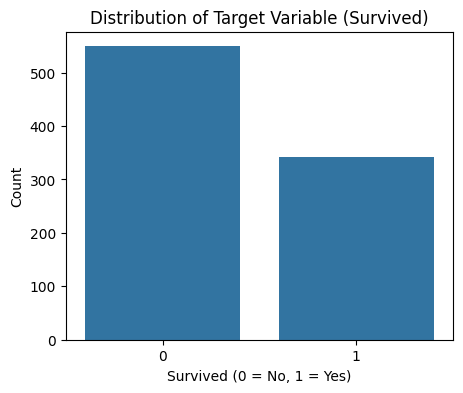

In [7]:
survived_counts = model_df["survived"].value_counts()
survived_pct = model_df["survived"].value_counts(normalize=True) * 100

print("Target distribution (counts):\n", survived_counts)
print("\nTarget distribution (%):\n", survived_pct.round(1))

plt.figure(figsize=(5, 4))
sns.countplot(x="survived", data=model_df)
plt.title("Distribution of Target Variable (Survived)")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Data is imbalanced, lesser survival rate this affects model accuracy scores

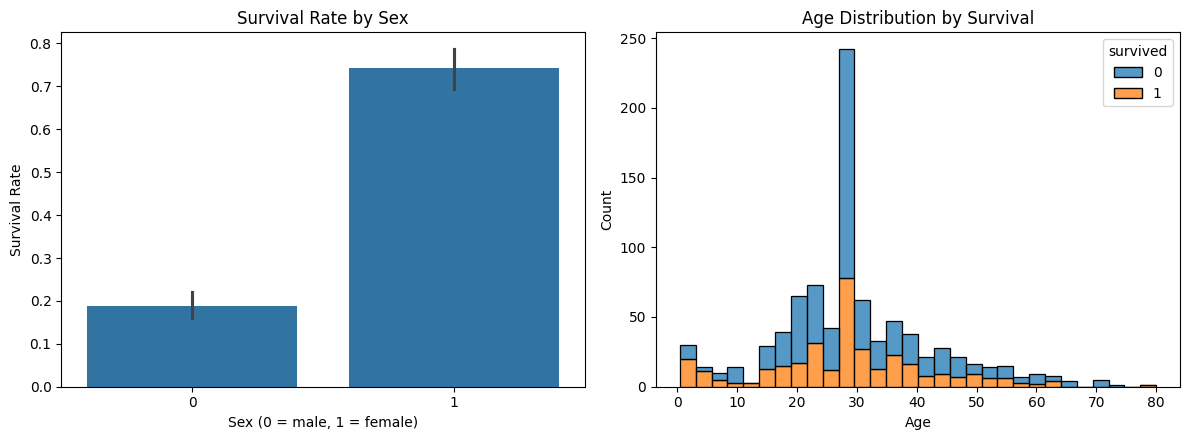

Survival rate by sex:
 sex
0    0.189
1    0.742
Name: survived, dtype: float64
Average age by survival:
 survived
0    30.03
1    28.29
Name: age, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x="sex", y="survived", data=model_df, ax=axes[0])
axes[0].set_title("Survival Rate by Sex")
axes[0].set_xlabel("Sex (0 = male, 1 = female)")
axes[0].set_ylabel("Survival Rate")

sns.histplot(data=model_df, x="age", hue="survived", multiple="stack", bins=30, ax=axes[1])
axes[1].set_title("Age Distribution by Survival")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

print("Survival rate by sex:\n", model_df.groupby("sex")["survived"].mean().round(3))
print("Average age by survival:\n", model_df.groupby("survived")["age"].mean().round(2))

We can see as shown in the movie the children and the women were given more importance

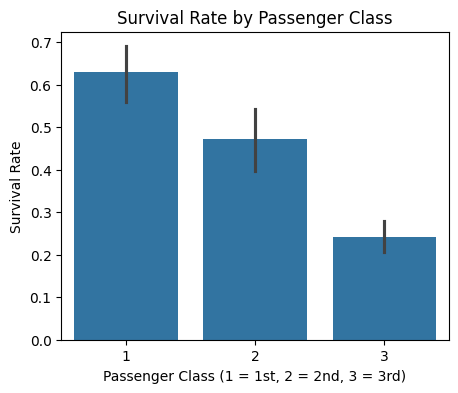

Survival rate by class:
 pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64


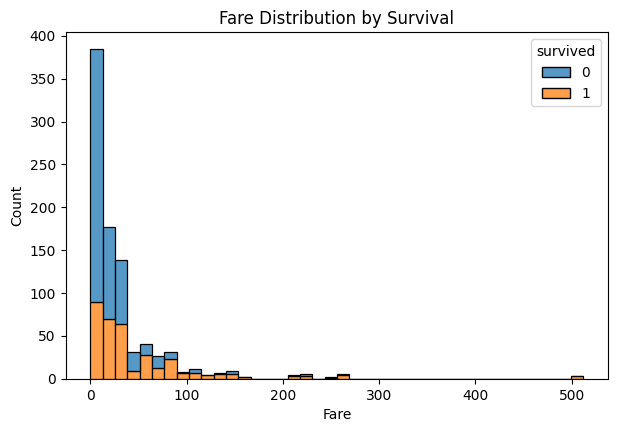

Average fare by survival:
 survived
0    22.12
1    48.40
Name: fare, dtype: float64


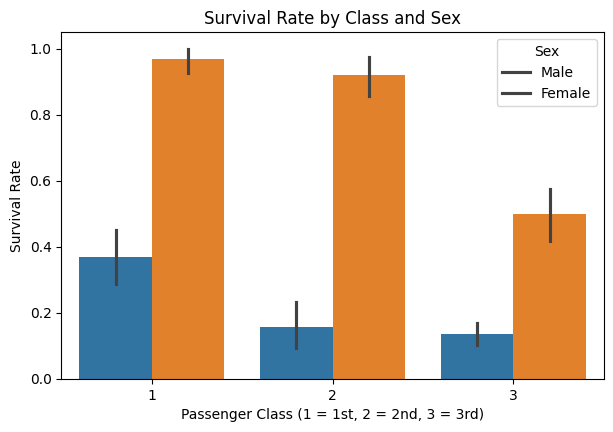

Survival rate by class and sex:
 pclass  sex
1       0      0.369
        1      0.968
2       0      0.157
        1      0.921
3       0      0.135
        1      0.500
Name: survived, dtype: float64


In [10]:
plt.figure(figsize=(5, 4))
sns.barplot(x="pclass", y="survived", data=model_df)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)")
plt.ylabel("Survival Rate")
plt.show()

print("Survival rate by class:\n", model_df.groupby("pclass")["survived"].mean().round(3))

plt.figure(figsize=(7, 4.5))
sns.histplot(data=model_df, x="fare", hue="survived", multiple="stack", bins=40)
plt.title("Fare Distribution by Survival")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

print("Average fare by survival:\n", model_df.groupby("survived")["fare"].mean().round(2))

plt.figure(figsize=(7, 4.5))
sns.barplot(x="pclass", y="survived", hue="sex", data=model_df)
plt.title("Survival Rate by Class and Sex")
plt.xlabel("Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)")
plt.ylabel("Survival Rate")
plt.legend(title="Sex", labels=["Male", "Female"])
plt.show()

print("Survival rate by class and sex:\n", model_df.groupby(["pclass", "sex"])["survived"].mean().round(3))

Similarly the rich and upper class people got importance and hence survived more, also just a speculation the men in lower class survived less showing they were less selfish and helped their women and children more

Data split

In [11]:
X = model_df.drop(columns=["survived"])
y = model_df["survived"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

val_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=val_ratio, random_state=SEED, stratify=y_train_full
)

print("Train:", X_train.shape, " Validation:", X_val.shape, " Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train: (623, 8)  Validation: (134, 8)  Test: (134, 8)


Custom Neural Network

In [12]:
n_features = X_train_scaled.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(16, activation="relu", name="hidden_1"),
    layers.Dense(8, activation="relu", name="hidden_2"),
    layers.Dense(1, activation="sigmoid", name="output"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.4157 - loss: 0.7205 - val_accuracy: 0.4478 - val_loss: 0.7049
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5040 - loss: 0.6969 - val_accuracy: 0.5224 - val_loss: 0.6873
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5682 - loss: 0.6774 - val_accuracy: 0.5746 - val_loss: 0.6722
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6164 - loss: 0.6585 - val_accuracy: 0.6045 - val_loss: 0.6575
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6421 - loss: 0.6399 - val_accuracy: 0.6194 - val_loss: 0.6420
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6677 - loss: 0.6215 - val_accuracy: 0.6418 - val_loss: 0.6253
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6966 - loss: 0.6029 - val_accuracy: 0.6716 - val_loss: 0.6073
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7223 - loss: 0.5839 - val_accuracy: 0.7015 - 

Model stops at 82 since loss stops decreasing to stop overfitting

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Accuracy : 0.784
Precision: 0.789
Recall   : 0.588
F1-score : 0.674


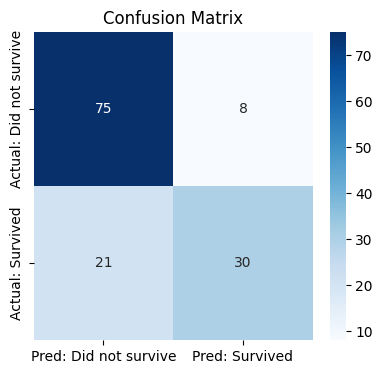


Full classification report:
               precision    recall  f1-score   support

           0       0.78      0.90      0.84        83
           1       0.79      0.59      0.67        51

    accuracy                           0.78       134
   macro avg       0.79      0.75      0.76       134
weighted avg       0.78      0.78      0.78       134



In [14]:
y_test_proba = model.predict(X_test_scaled).ravel()
y_test_pred = (y_test_proba >= 0.5).astype(int)

acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Did not survive", "Pred: Survived"],
            yticklabels=["Actual: Did not survive", "Actual: Survived"])
plt.title("Confusion Matrix")
plt.show()

print("\nFull classification report:\n", classification_report(y_test, y_test_pred))

Model is better at predicting who did not survive since the imbalance in the dataset pointed earlier

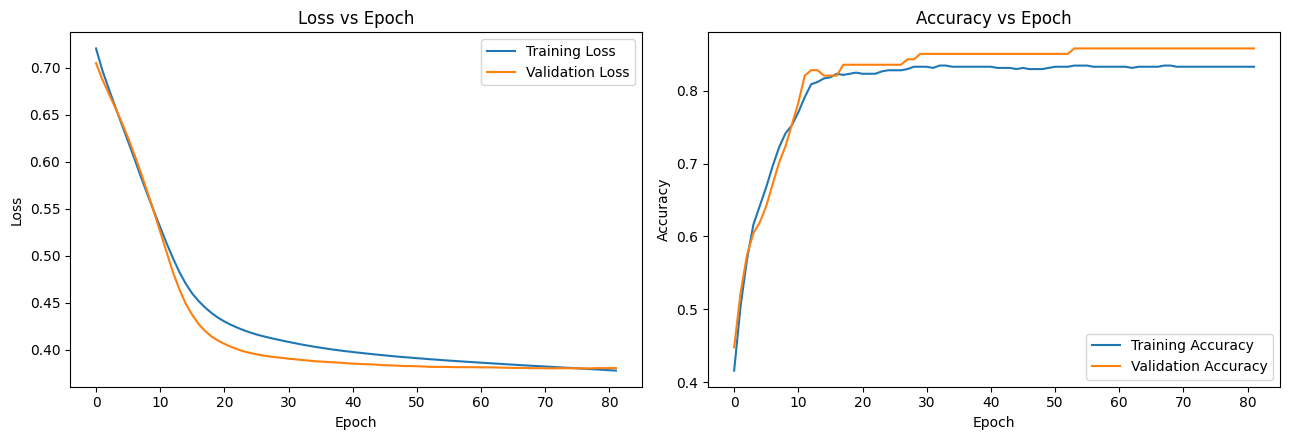

In [15]:
hist = history.history

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(hist["loss"], label="Training Loss")
axes[0].plot(hist["val_loss"], label="Validation Loss")
axes[0].set_title("Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(hist["accuracy"], label="Training Accuracy")
axes[1].plot(hist["val_accuracy"], label="Validation Accuracy")
axes[1].set_title("Accuracy vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

Model stopped at 82 epochs as we can see from the graph the loss was not decreasing significatnly

Comparision 1 hidden layer vs 2 hidden layer

In [16]:
def build_and_train(hidden_layers, name, epochs=100, batch_size=32, verbose=0):
    m = keras.Sequential([layers.Input(shape=(n_features,))])
    for i, units in enumerate(hidden_layers):
        m.add(layers.Dense(units, activation="relu", name=f"hidden_{i+1}"))
    m.add(layers.Dense(1, activation="sigmoid", name="output"))

    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    h = m.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val),
              epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=verbose)

    proba = m.predict(X_test_scaled, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)

    return {
        "name": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    }

results = []
results.append(build_and_train([16], "1 hidden layer (16 units)"))
results.append(build_and_train([16, 8], "2 hidden layers (16 -> 8 units)"))

comparison_df = pd.DataFrame(results).set_index("name").round(3)
comparison_df

,accuracy,precision,recall,f1
name,,,,
1 hidden layer (16 units),0.769,0.750,0.588,0.659
2 hidden layers (16 -> 8 units),0.784,0.789,0.588,0.674


Both models perform similar hence showing that for a smaller and simpler dataset 2 layers is too much and 1 would suffice

Predictions

In [17]:
sample_idx = X_test.index[:5]
sample_X = X_test.loc[sample_idx]
sample_X_scaled = scaler.transform(sample_X)

sample_proba = model.predict(sample_X_scaled, verbose=0).ravel()
sample_pred = (sample_proba >= 0.5).astype(int)

results_df = sample_X.copy()
results_df["actual_survived"] = y_test.loc[sample_idx].values
results_df["predicted_probability"] = sample_proba.round(3)
results_df["predicted_survived"] = sample_pred

results_df

,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S,actual_survived,predicted_probability,predicted_survived
799,3,1,30.0,1,1,24.1500,False,True,0,0.453,0
553,3,0,22.0,0,0,7.2250,False,False,1,0.171,0
541,3,1,9.0,4,2,31.2750,False,True,0,0.164,0
441,3,0,20.0,0,0,9.5000,False,True,0,0.119,0
685,2,0,25.0,1,2,41.5792,False,False,0,0.450,0


As we can see since the model already has bias on men not surviving due to the precentage it predicts a 3rd class man survivng wrong due to its rarity

Important features

Correlation with 'survived' (sorted by strength):
 sex           0.543
pclass       -0.338
fare          0.257
embarked_S   -0.150
parch         0.082
age          -0.065
sibsp        -0.035
embarked_Q    0.004
Name: survived, dtype: float64


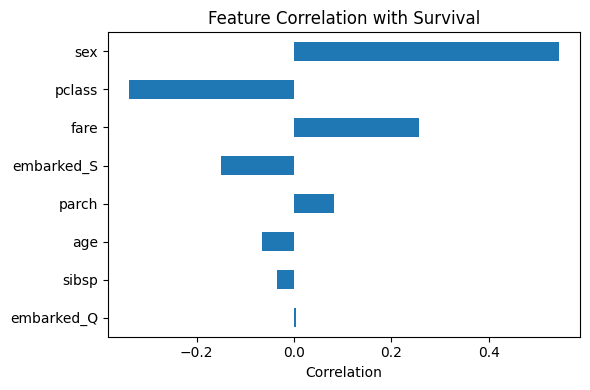

In [18]:
corr_with_target = model_df.corr(numeric_only=True)["survived"].drop("survived").sort_values(key=abs, ascending=False)
print("Correlation with 'survived' (sorted by strength):\n", corr_with_target.round(3))

plt.figure(figsize=(6, 4))
corr_with_target.plot(kind="barh")
plt.title("Feature Correlation with Survival")
plt.xlabel("Correlation")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

As discussed and shown from the EDA sex and class have the highest impact on survival, fare correlates to class and S is likely a place of lower class people hence people not from there survived more

Learning rate comparisions

In [19]:
from tensorflow.keras.optimizers import Adam

def build_and_train_lr(learning_rate, name, epochs=100, batch_size=32, verbose=0):
    m = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])

    m.compile(optimizer=Adam(learning_rate=learning_rate),
              loss="binary_crossentropy", metrics=["accuracy"])
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    m.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val),
          epochs=epochs, batch_size=batch_size, callbacks=[es], verbose=verbose)

    proba = m.predict(X_test_scaled, verbose=0).ravel()
    pred = (proba >= 0.5).astype(int)

    return {
        "name": name,
        "learning_rate": learning_rate,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    }

lr_results = []
lr_results.append(build_and_train_lr(0.1,    "Learning rate = 0.1 (high)"))
lr_results.append(build_and_train_lr(0.001,  "Learning rate = 0.001 (Adam's default)"))
lr_results.append(build_and_train_lr(0.0001, "Learning rate = 0.0001 (low)"))

lr_comparison_df = pd.DataFrame(lr_results).set_index("name").round(3)
lr_comparison_df

,learning_rate,accuracy,precision,recall,f1
name,,,,,
Learning rate = 0.1 (high),0.100,0.761,0.806,0.490,0.610
Learning rate = 0.001 (Adam's default),0.001,0.776,0.769,0.588,0.667
Learning rate = 0.0001 (low),0.000,0.746,0.707,0.569,0.630


As we fine tune lr we can't see much difference although we can see higher lr perfoming a bit worse than default since it adjusts the weights more aggresively hence even though it hasa better precision it fails at recall showing it misjudged much more than default

Custom NN vs Traditional models

In [20]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

traditional_models = {
    "Logistic Regression": LogisticRegression(random_state=SEED),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED),
}

model_comparison_results = []

model_comparison_results.append({
    "model": "Neural Network (ours)",
    "accuracy": acc, "precision": prec, "recall": rec, "f1": f1
})

for name, clf in traditional_models.items():
    clf.fit(X_train_scaled, y_train)
    pred = clf.predict(X_test_scaled)

    model_comparison_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    })

model_comparison_df = pd.DataFrame(model_comparison_results).set_index("model").round(3)
model_comparison_df


,accuracy,precision,recall,f1
model,,,,
Neural Network (ours),0.784,0.789,0.588,0.674
Logistic Regression,0.776,0.744,0.627,0.681
Decision Tree,0.716,0.627,0.627,0.627
Random Forest,0.761,0.711,0.627,0.667


Even though our NN has a better accuracy and precision it failed at recall. Since this was a small dataset the added complexity of trained MLs didnt contribute much